# 1.load data

In [1]:
import numpy as np
import gprlim
from gprlim import models

# (Nbls, Ntimes, Nfreq, Npol)=(1,1600,600,1)

# EoR only
d_eor = np.load("generate_data/eor_data.npz", allow_pickle=True)
eor_data_raw = d_eor["data"]
freqs_eor = d_eor["freqs"]   # unit MHz
times_eor = d_eor["times"]

# EoR + foreground
d_fg = np.load("generate_data/eor_fg_data.npz", allow_pickle=True)
eor_fg_data_raw = d_fg["data"]

# EoR + foreground + noise
d_efn = np.load("generate_data/eor_fg_noise.npz", allow_pickle=True)
eor_fg_noise_raw = d_efn["data"]

# Thermal noise
d_noise = np.load("generate_data/noise.npz", allow_pickle=True)
noise_raw = d_noise["noise"]
noise_var_raw = d_noise["noise_var"]


# Flags
d_flag = np.load("generate_data/flags.npz", allow_pickle=True)
flags_raw = d_flag["flags"]

# Check original shapes
print("Original shapes")
print("eor_data_raw      :", eor_data_raw.shape)
print("eor_fg_data_raw   :", eor_fg_data_raw.shape)
print("eor_fg_noise_raw  :", eor_fg_noise_raw.shape)
print("noise_raw         :", noise_raw.shape)
print("noise_var_raw     :", noise_var_raw.shape)
print("flags_raw         :", flags_raw.shape)




Original shapes
eor_data_raw      : (1, 1600, 600, 1)
eor_fg_data_raw   : (1, 1600, 600, 1)
eor_fg_noise_raw  : (1, 1600, 600, 1)
noise_raw         : (1, 1600, 600, 1)
noise_var_raw     : (1, 1600, 600, 1)
flags_raw         : (1, 1600, 600, 1)


# cut part

In [2]:
# (1, 1600, 600, 1) -> (1, 20, 180, 1)

eor_data_raw      = eor_data_raw[:, :20, :, :]
eor_fg_data_raw   = eor_fg_data_raw[:, :20, :, :]
eor_fg_noise_raw  = eor_fg_noise_raw[:, :20, :, :]
noise_raw         = noise_raw[:, :20, :, :]
noise_var_raw     = noise_var_raw[:, :20, :, :]
flags_raw         = flags_raw[:, :20, :, :]

# 如果频率数组长度是 600，也同步截取
freqs_eor = freqs_eor[:]

# 如果 times_eor 长度是 1600，也同步截取
times_eor = times_eor[:20]

print("\nTrimmed shapes")
print("eor_data_raw      :", eor_data_raw.shape)
print("eor_fg_data_raw   :", eor_fg_data_raw.shape)
print("eor_fg_noise_raw  :", eor_fg_noise_raw.shape)
print("noise_raw         :", noise_raw.shape)
print("noise_var_raw     :", noise_var_raw.shape)
print("flags_raw         :", flags_raw.shape)


Trimmed shapes
eor_data_raw      : (1, 20, 600, 1)
eor_fg_data_raw   : (1, 20, 600, 1)
eor_fg_noise_raw  : (1, 20, 600, 1)
noise_raw         : (1, 20, 600, 1)
noise_var_raw     : (1, 20, 600, 1)
flags_raw         : (1, 20, 600, 1)


In [3]:
# convert: (Nbls, Ntimes, Nfreq, Npol)
#       -> (Npol, Nbls，Ntimes,  Nfreq)

eor_data     = np.transpose(eor_data_raw,     (3, 0, 1, 2))
eor_fg_data  = np.transpose(eor_fg_data_raw,  (3, 0, 1, 2))
eor_fg_noise = np.transpose(eor_fg_noise_raw, (3, 0, 1, 2))
noise         = np.transpose(noise_raw,        (3, 0, 1, 2))
noise_var     = np.transpose(noise_var_raw,    (3, 0, 1, 2))
flags         = np.transpose(flags_raw,        (3, 0, 1, 2))

# Check converted shapes
print("\nConverted shapes")
print("eor_data      :", eor_data.shape)
print("eor_fg_data   :", eor_fg_data.shape)
print("eor_fg_noise  :", eor_fg_noise.shape)
print("noise         :", noise.shape)
print("noise_var     :", noise_var.shape)
print("flags         :", flags.shape)


Converted shapes
eor_data      : (1, 1, 20, 600)
eor_fg_data   : (1, 1, 20, 600)
eor_fg_noise  : (1, 1, 20, 600)
noise         : (1, 1, 20, 600)
noise_var     : (1, 1, 20, 600)
flags         : (1, 1, 20, 600)


In [4]:
import numpy as np
from matplotlib import pyplot as plt
#d = np.load("/Users/alliswell48/simpleQE/notebooks/generate_datat/gpr_inpaint_input.npz")

#fchans = [(20, 21), (40, 41), (80, 81), (95, 96), (120, 121),[170,171]]

data0 = eor_fg_noise
inp_flags0 = flags 
inv_wgts0 = noise_var
freqs0 = freqs_eor
fg0=eor_fg_data -eor_data 
noise0=noise



inv_wgts0 = inv_wgts0.copy()
inv_wgts0[inp_flags0] = 2e10     # ≫ outputscale(1e3),又 ≪ 1e10


print(data0.shape)
print(inp_flags0.shape)
print(inv_wgts0.shape)
print(freqs0.shape)
print(fg0.shape)
print(noise0.shape)

(1, 1, 20, 600)
(1, 1, 20, 600)
(1, 1, 20, 600)
(600,)
(1, 1, 20, 600)
(1, 1, 20, 600)


In [5]:
import torch

# numpy → torch
data = torch.tensor(data0)
inp_flags = torch.tensor(inp_flags0)
inv_wgts = torch.tensor(inv_wgts0)
freqs = torch.tensor(freqs0)

# 统一 dtype
freqs = freqs.double()               # Hz, float32
data = data.to(torch.complex128)     # complex64
inv_wgts = inv_wgts.double()         # float32
inp_flags = inp_flags.bool()        # bool

# 检查
print("data.shape =", data.shape)
print("inp_flags.shape =", inp_flags.shape)
print("inv_wgts.shape =", inv_wgts.shape)
print("freqs.shape =", freqs.shape)

print("data.dtype =", data.dtype)
print("inp_flags.dtype =", inp_flags.dtype)
print("inv_wgts.dtype =", inv_wgts.dtype)
print("freqs.dtype =", freqs.dtype)

data.shape = torch.Size([1, 1, 20, 600])
inp_flags.shape = torch.Size([1, 1, 20, 600])
inv_wgts.shape = torch.Size([1, 1, 20, 600])
freqs.shape = torch.Size([600])
data.dtype = torch.complex128
inp_flags.dtype = torch.bool
inv_wgts.dtype = torch.float64
freqs.dtype = torch.float64


20

# 2.load gp output

In [16]:
import torch
import numpy as np
# 读取模型
model = torch.load("output/gpr_model.pt")

# 读取结果
d = np.load("output/gpr_outputs.npz", allow_pickle=True)

inp_y = d["inp_y"]
mdl = d["mdl"]
y_offset = d["y_offset"]

Ntimes=inp_y.shape[1]

In [7]:
for name, param in model.named_parameters():

    if not param.requires_grad:
        continue

    attr_name = name.replace("raw_", "")

    obj = model
    for attr in attr_name.split("."):
        obj = getattr(obj, attr)

    value = obj.flatten()[0].item() if obj.ndim > 0 else obj.item()

    print(f"{name:70s} -> {value:.4f}")

covar.raw_outputscale                                                  -> 40.0832
covar.base_kernel.kernels.0.raw_lengthscale                            -> 5.2795
covar.base_kernel.kernels.1.raw_outputscale                            -> 34.2026
covar.base_kernel.kernels.1.base_kernel.kernels.0.raw_lengthscale      -> 9.7649
covar.base_kernel.kernels.1.base_kernel.kernels.1.raw_outputscale      -> 0.0497
covar.base_kernel.kernels.1.base_kernel.kernels.1.base_kernel.raw_lengthscale -> 5.2820


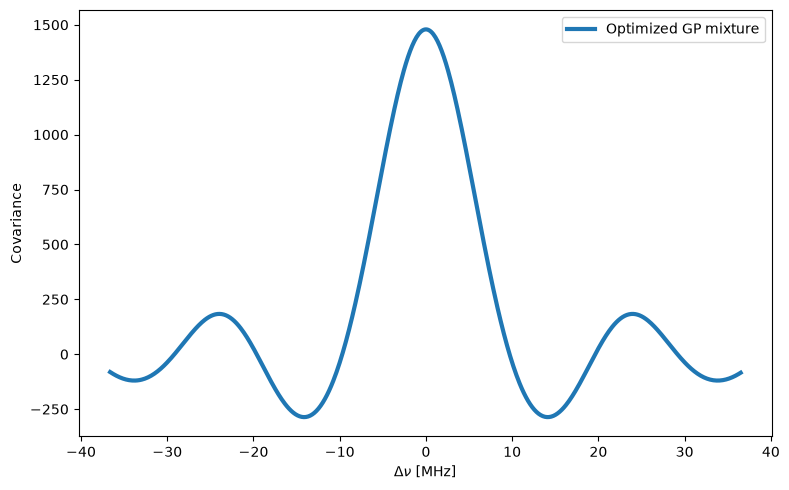

In [9]:
# optimized mixture kernel
with torch.no_grad():
    K_mix = model.covar(model.train_inputs[0]).to_dense().squeeze().cpu().numpy()


freqs_mhz = freqs 
i0 = len(freqs) // 2
dnu = freqs_mhz - freqs_mhz[i0]

plt.figure(figsize=(8,5))

# GP mixture kernel
plt.plot(
    dnu,
    K_mix[i0],
    lw=3,
    label="Optimized GP mixture"
)



plt.xlabel(r"$\Delta \nu$ [MHz]")
plt.ylabel("Covariance")
plt.legend()
plt.tight_layout()

# 3. inpaint

In [10]:
import numpy as np

def flags_to_fchans(flag_array):
    """
    Convert a 1D boolean flag array into a list of
    contiguous flagged channel ranges.

    Parameters
    ----------
    flag_array : ndarray of bool, shape (Nfreq,)

    Returns
    -------
    fchans : list of tuple
        Example:
        [(38, 41), (61, 61), (80, 80), (132, 155)]
    """
    idx = np.where(flag_array)[0]

    if len(idx) == 0:
        return []

    fchans = []
    start = prev = idx[0]

    for i in idx[1:]:
        if i == prev + 1:
            prev = i
        else:
            fchans.append((start, prev))
            start = prev = i

    fchans.append((start, prev))

    return fchans





[(38, 41), (61, 61), (81, 81), (131, 133), (135, 135), (137, 150), (152, 152), (175, 177), (180, 181), (187, 187), (191, 191), (194, 195), (201, 201), (203, 203), (207, 213), (221, 227), (229, 229), (232, 232), (238, 238), (244, 244), (276, 276), (279, 280), (286, 286), (288, 288), (293, 294), (302, 302), (312, 313), (315, 315), (320, 321), (338, 338), (340, 340), (408, 409), (411, 411), (416, 416), (419, 419), (423, 423), (451, 451), (500, 501), (503, 503), (514, 521), (523, 523), (543, 543), (551, 553), (566, 568), (570, 575), (577, 577), (582, 584), (599, 599)]


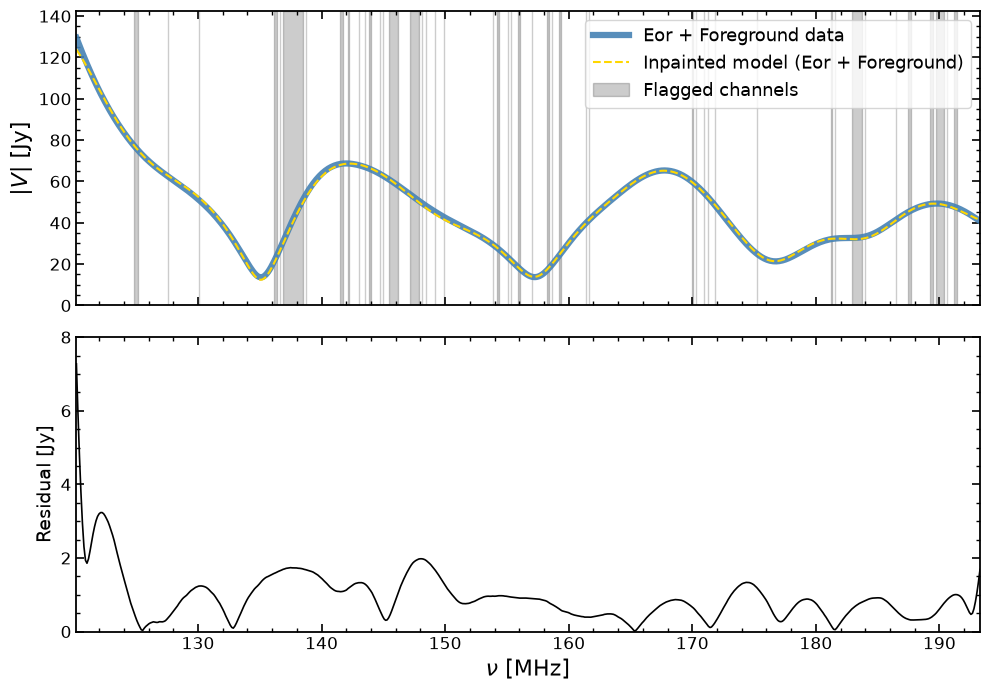

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# x range (MHz)
xlim = (freqs.min(), freqs.max())

# ==========================================
# Top panel
# ==========================================
ax = axes[0]

# Tick style
ax.tick_params(axis='both', which='major',
               labelsize=12, direction='in',
               length=6, width=1.2,
               top=True, right=True)

ax.tick_params(axis='both', which='minor',
               direction='in',
               length=3, width=1.0,
               top=True, right=True)

ax.minorticks_on()

# Flagged channels
fchans = flags_to_fchans(flags[0, 0, 1, :])
print(fchans)

for fc in fchans:
    ax.axvspan(
        freqs[fc[0]],
        freqs[fc[1]],
        color='k',
        alpha=0.2
    )

# Original data
vis = np.abs(eor_fg_data[0, 0, 1, :])

p0, = ax.plot(
    freqs,
    vis,
    lw=4.5,
    color='steelblue',
    alpha=0.9
)

# Inpainted model
mdl_abs = np.abs(mdl[0, 1, :])

p1, = ax.plot(
    freqs,
    mdl_abs,
    lw=1.5,
    color='gold',
    ls='--'
)

# Legend patch
r = plt.Rectangle((0, 0), 0, 0, color='k', alpha=0.2)

ax.legend(
    [p0, p1, r],
    ['Eor + Foreground data',
     'Inpainted model (Eor + Foreground)',
     'Flagged channels'],
    fontsize=13
)

# Automatic axis limits
ax.set_xlim(xlim)
ax.set_ylim(0, 1.1 * max(vis.max(), mdl_abs.max()))

ax.set_ylabel(r'$|V|$ [Jy]', fontsize=16)

# Thicker frame
for spine in ax.spines.values():
    spine.set_linewidth(1.3)

# ==========================================
# Bottom panel
# ==========================================
ax = axes[1]

ax.tick_params(axis='both', which='major',
               labelsize=12, direction='in',
               length=6, width=1.2,
               top=True, right=True)

ax.tick_params(axis='both', which='minor',
               direction='in',
               length=3, width=1.0,
               top=True, right=True)

ax.minorticks_on()

# Residual
resid = mdl[0, 1, :] - eor_fg_data[0, 0, 1, :]
resid_abs = np.abs(resid)  #/abs(mdl[0, 1, :])

ax.plot(
    freqs,
    resid_abs,
    color='k',
    lw=1.2
)

# Automatic limits
ax.set_xlim(xlim)
ax.set_ylim(0, 1.1 * resid_abs.max())

ax.set_xlabel(r'$\nu$ [MHz]', fontsize=16)
ax.set_ylabel(r'Residual [Jy]', fontsize=14)

for spine in ax.spines.values():
    spine.set_linewidth(1.3)

plt.tight_layout()
plt.show()

In [50]:
eor_fg_data

array([[[[-61.04239858+115.10462629j, -57.70775585+114.66529447j,
          -54.49630771+114.12602385j, ...,  32.92971865 -25.77914895j,
           31.57034965 -26.68181566j,  31.89270621 -24.5706745j ],
         [-59.26030365+115.17849781j, -55.93108222+114.72681413j,
          -52.72554285+114.1754724j , ...,  32.79847723 -25.93756798j,
           31.43658035 -26.83801656j,  31.50057226 -26.89726269j],
         [-57.46956627+115.19750769j, -54.14581593+114.73333157j,
          -50.94623272+114.16981925j, ...,  32.6511666  -26.09055796j,
           31.28663327 -26.9884912j ,  31.70713506 -26.83041456j],
         ...,
         [-31.87773522+110.90992918j, -28.64180033+110.29071809j,
          -25.53646232+109.57799364j, ...,  30.17527746 -27.45090762j,
           28.77990882 -28.30796553j,  26.94517605 -28.37719752j],
         [-30.30543716+110.31617483j, -27.07554903+109.68790169j,
          -23.97658709+108.96654703j, ...,  30.01672781 -27.50602478j,
           28.62036764 -28.360585

In [51]:
vi7.shape

(1, 1, 20, 600)

# 4. Inpaint all time–frequency samples

# 4.1 true Eor + fg

Text(0.5, 0, 'Frequency [MHz]')

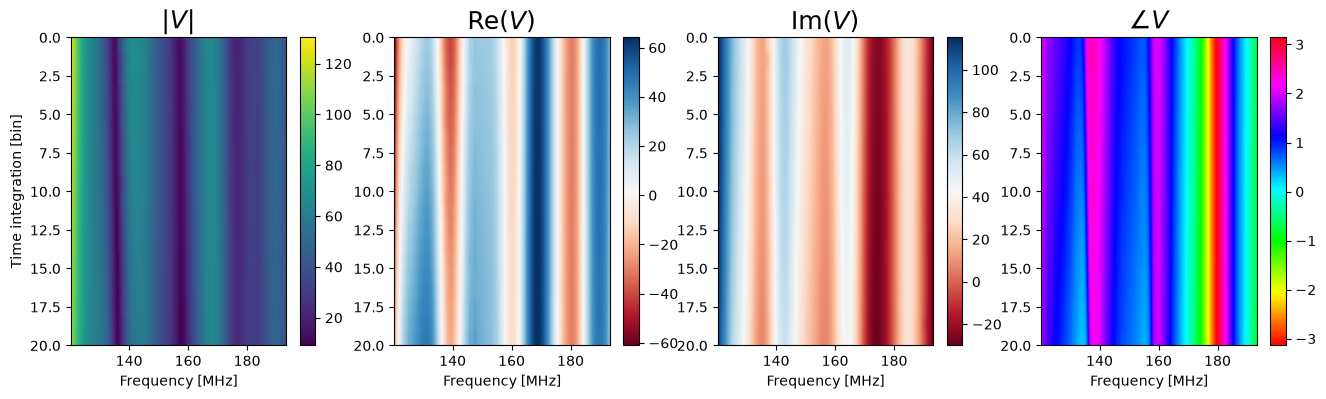

In [53]:
vi7 = eor_fg_data

# Plot the noisy visibility waterfall
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Visibility amplitude |V|
cax = axes[0].imshow(
    abs(vi7[0, 0, :, :]),
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    interpolation="none",
)
axes[0].set_title(r"$|V|$", fontsize=18)
plt.colorbar(cax, ax=axes[0])
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Time integration [bin]")

# Real part of visibility
cax = axes[1].imshow(
    vi7[0, 0, :, :].real,
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    cmap="RdBu",
)
axes[1].set_title(r"$\mathrm{Re}(V)$", fontsize=18)
plt.colorbar(cax, ax=axes[1])
axes[1].set_xlabel("Frequency [MHz]")

# Imaginary part of visibility
cax = axes[2].imshow(
    vi7[0, 0, :, :].imag,
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    cmap="RdBu",
)
axes[2].set_title(r"$\mathrm{Im}(V)$", fontsize=18)
plt.colorbar(cax, ax=axes[2])
axes[2].set_xlabel("Frequency [MHz]")

# Visibility phase
cax = axes[3].imshow(
    np.angle(vi7[0, 0, :, :]),
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    cmap="hsv",
)
axes[3].set_title(r"$\angle V$", fontsize=18)
plt.colorbar(cax, ax=axes[3])
axes[3].set_xlabel("Frequency [MHz]")

# 4.2 flaged Eor + fg 

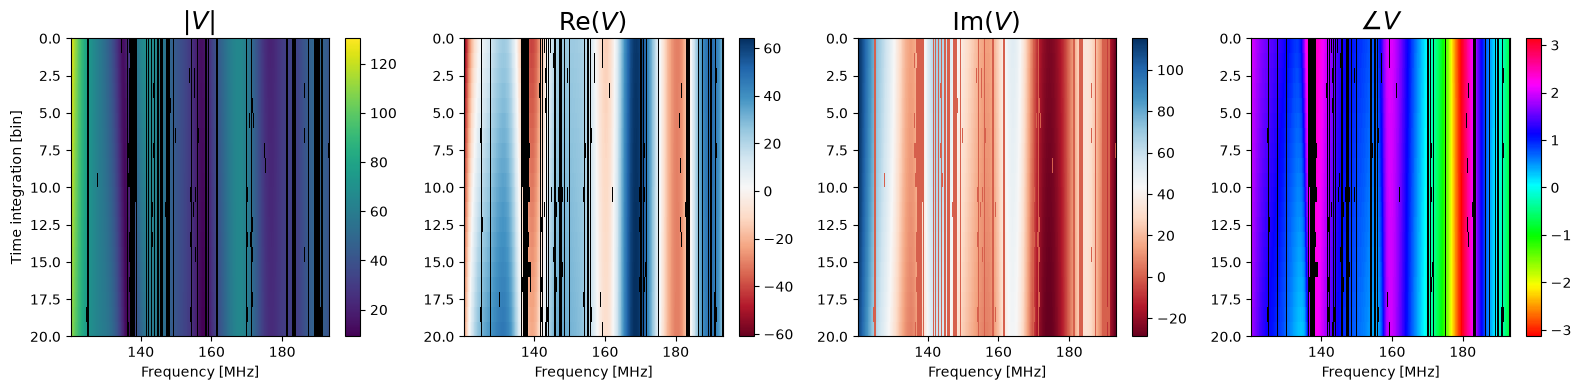

In [54]:
# Copy the data so the original array is not modified
data_plot = eor_fg_data.copy()

# Set flagged samples to NaN
data_plot[flags] = torch.nan

# Colormaps: show NaN values in black
cmap_amp = plt.cm.viridis.copy()
cmap_amp.set_bad(color="black")

cmap_rb = plt.cm.RdBu.copy()
cmap_rb.set_bad(color="black")

cmap_phase = plt.cm.hsv.copy()
cmap_phase.set_bad(color="black")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# |V|
cax = axes[0].imshow(
    np.abs(data_plot[0, 0, :, :]),
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    interpolation="none",
    cmap=cmap_amp,
)
axes[0].set_title(r"$|V|$", fontsize=18)
plt.colorbar(cax, ax=axes[0])
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Time integration [bin]")

# real(V)
cax = axes[1].imshow(
    data_plot[0, 0, :, :].real,
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    interpolation="none",
    cmap=cmap_rb,
)
axes[1].set_title(r"$\mathrm{Re}(V)$", fontsize=18)
plt.colorbar(cax, ax=axes[1])
axes[1].set_xlabel("Frequency [MHz]")

# imag(V)
cax = axes[2].imshow(
    data_plot[0, 0, :, :].imag,
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    interpolation="none",
    cmap=cmap_rb,
)
axes[2].set_title(r"$\mathrm{Im}(V)$", fontsize=18)
plt.colorbar(cax, ax=axes[2])
axes[2].set_xlabel("Frequency [MHz]")

# angle(V)
cax = axes[3].imshow(
    np.angle(data_plot[0, 0, :, :]),
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    interpolation="none",
    cmap=cmap_phase,
)
axes[3].set_title(r"$\angle V$", fontsize=18)
plt.colorbar(cax, ax=axes[3])
axes[3].set_xlabel("Frequency [MHz]")

plt.tight_layout()

# 4.3 recovery Eor + fg 

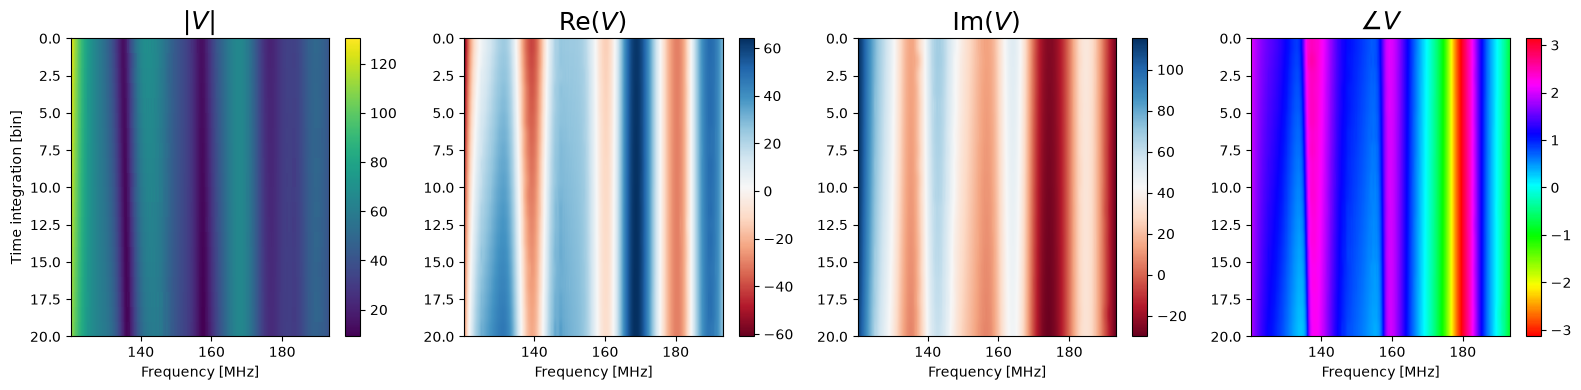

In [65]:
# Copy the data so the original array is not modified
vi7 = eor_fg_data.copy()

# Replace flagged samples with the GP model
vi7[flags] = mdl[flags[0,:,:,:]]

# Plot the inpainted visibility waterfall
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Visibility amplitude |V|
cax = axes[0].imshow(
    np.abs(vi7[0, 0, :, :]),
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    interpolation="none",
)
axes[0].set_title(r"$|V|$", fontsize=18)
plt.colorbar(cax, ax=axes[0])
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Time integration [bin]")

# Real part
cax = axes[1].imshow(
    vi7[0, 0, :, :].real,
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    cmap="RdBu",
)
axes[1].set_title(r"$\mathrm{Re}(V)$", fontsize=18)
plt.colorbar(cax, ax=axes[1])
axes[1].set_xlabel("Frequency [MHz]")

# Imaginary part
cax = axes[2].imshow(
    vi7[0, 0, :, :].imag,
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    cmap="RdBu",
)
axes[2].set_title(r"$\mathrm{Im}(V)$", fontsize=18)
plt.colorbar(cax, ax=axes[2])
axes[2].set_xlabel("Frequency [MHz]")

# Phase
cax = axes[3].imshow(
    np.angle(vi7[0, 0, :, :]),
    aspect="auto",
    extent=[freqs[0], freqs[-1], Ntimes, 0],
    cmap="hsv",
)
axes[3].set_title(r"$\angle V$", fontsize=18)
plt.colorbar(cax, ax=axes[3])
axes[3].set_xlabel("Frequency [MHz]")

plt.tight_layout()